In [ ]:
!pip install roboflow

from roboflow import Roboflow
rf = Roboflow(api_key="ovTJX8pKuMfwL8NIouvr")
project = rf.workspace("itrash").project("apple-khthj")
version = project.version(4)
dataset = version.download("yolo26")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 250.0/250.0 kB 5.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 14.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 36.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 59.8 MB/s eta 0:00:00
  Attempting uninstall: opencv-python-headless
    Found existing installation: opencv-python-headless 4.13.0.92
    Uninstalling opencv-python-headless-4.13.0.92:
      Successfully uninstalled opencv-python-headless-4.13.0.92
  Attempting uninstall: idna
    Found existing installation: idna 3.18
    Uninstalling idna-3.18:
      Successfully uninstalled idna-3.18
loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to Apple-4 in yolo26:: 100%|██████████| 6755/6755 [00:01<00:00, 3554.11it/s]


In [ ]:
!pip install roboflow

from roboflow import Roboflow
rf = Roboflow(api_key="ovTJX8pKuMfwL8NIouvr")
project = rf.workspace("dragon-fruit-un3xe").project("banana-gh2yn")
version = project.version(1)
dataset = version.download("yolo26")


loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to Banana-1 in yolo26:: 100%|██████████| 19190/19190 [00:05<00:00, 3814.04it/s]


In [ ]:
!pip install roboflow

from roboflow import Roboflow
rf = Roboflow(api_key="uh1spePMhm5CTcMVKALU")
project = rf.workspace("new-tomato-detection").project("tomato-detection-wb9kx")
version = project.version(4)
dataset = version.download("yolo26")


loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to TOMATO-DETECTION-4 in yolo26:: 100%|██████████| 34695/34695 [00:08<00:00, 4013.26it/s]


In [ ]:
import yaml
from collections import Counter
from pathlib import Path

DATASET_PATH = "/content/TOMATO-DETECTION-4"
YAML_PATH = "/content/TOMATO-DETECTION-4/data.yaml"

with open(YAML_PATH, "r") as f:
    data_cfg = yaml.safe_load(f)

class_names = data_cfg["names"]

box_counter = Counter()
image_counter = Counter()

for split in ["train", "valid", "test"]:
    label_dir = Path(DATASET_PATH) / split / "labels"

    for label_file in label_dir.glob("*.txt"):

        classes_in_image = set()

        with open(label_file, "r") as f:
            for line in f:
                parts = line.strip().split()

                if len(parts) >= 5:
                    cls = int(parts[0])

                    box_counter[cls] += 1
                    classes_in_image.add(cls)

        for cls in classes_in_image:
            image_counter[cls] += 1

print(f"{'Class':20s} {'Images':>10s} {'Boxes':>10s}")
print("-" * 45)

for cls_id, name in enumerate(class_names):
    print(
        f"{name:20s} "
        f"{image_counter[cls_id]:10d} "
        f"{box_counter[cls_id]:10d}"
    )

Class                    Images      Boxes
---------------------------------------------
Bad                        5958      10236
Good                       7979      19444
Unripe                     4385      19083


In [ ]:
import os
import shutil
from pathlib import Path


OUTPUT_DIR = Path("merged_dataset")
SPLITS = ["train", "valid", "val", "test"]

MASTER_CLASSES = {
    0: "apple_unripe", 1: "apple_ripe", 2: "apple_overripe",
    3: "banana_unripe", 4: "banana_ripe", 5: "banana_overripe",
    6: "tomato_unripe", 7: "tomato_ripe", 8: "tomato_bad",
}

DATASETS = {
    "tomato": {
        "source_dir": "/content/TOMATO-DETECTION-4", #
        "mapping": {
            2: 6,  # Unripe -> tomato_unripe
            1: 7,  # Good -> tomato_ripe
            0: 8   # Bad -> tomato_bad
        }
    },
    "banana": {
        "source_dir": "/content/Banana-1",
        "mapping": {
            1: 3, 5: 3,  # unripe
            0: 4, 3: 4,  # ripe + freshripe
            2: 5, 4: 5   # overripe + rotten
        }
    },
    "apple": {
        "source_dir": "/content/Apple-4",
        "mapping": {
            2: 0,  # unripe
            0: 1,  # ripe
            1: 2   # rotten -> overripe
        }
    }
}

def ensure_dirs():
    if OUTPUT_DIR.exists():
        print(f"[WARN] Thư mục {OUTPUT_DIR} đã tồn tại. Dữ liệu sẽ được ghi đè/thêm vào.")

    for split in ["train", "valid", "test"]:
        (OUTPUT_DIR / split / "images").mkdir(parents=True, exist_ok=True)
        (OUTPUT_DIR / split / "labels").mkdir(parents=True, exist_ok=True)

def convert_and_copy(fruit_name, cfg):
    src_dir = Path(cfg["source_dir"])
    mapping = cfg["mapping"]

    for split in SPLITS:
        img_split_dir = src_dir / split / "images"
        label_split_dir = src_dir / split / "labels"

        if not img_split_dir.exists() or not label_split_dir.exists():
            continue

        out_split = "valid" if split in ["val", "valid"] else split

        for img_file in img_split_dir.glob("*.*"):
            if img_file.suffix.lower() not in ['.jpg', '.jpeg', '.png']:
                continue

            stem = img_file.stem
            label_file = label_split_dir / f"{stem}.txt"

            new_filename = f"{fruit_name}_{stem}"
            new_labels = []

            if label_file.exists():
                with open(label_file, "r", encoding="utf-8") as f:
                    for line in f:
                        parts = line.strip().split()
                        if len(parts) < 5:
                            continue

                        cls = int(parts[0])
                        if cls in mapping:
                            parts[0] = str(mapping[cls])
                            new_labels.append(" ".join(parts))

            if not new_labels:
                continue

            out_label = OUTPUT_DIR / out_split / "labels" / f"{new_filename}.txt"
            with open(out_label, "w", encoding="utf-8") as f:
                f.write("\n".join(new_labels) + "\n")

            out_img = OUTPUT_DIR / out_split / "images" / f"{new_filename}{img_file.suffix}"
            shutil.copy(img_file, out_img)

def generate_yaml():
    yaml_path = OUTPUT_DIR / "data.yaml"
    names_str = "\n".join([f"  {k}: {v}" for k, v in MASTER_CLASSES.items()])
    content = f"""train: ../train/images
val: ../valid/images
test: ../test/images

nc: {len(MASTER_CLASSES)}
names:
{names_str}
"""
    with open(yaml_path, "w", encoding="utf-8") as f:
        f.write(content)

if __name__ == "__main__":
    ensure_dirs()

    for name, cfg in DATASETS.items():
        print(f"[INFO] Processing {name}...")
        convert_and_copy(name, cfg)

    generate_yaml()
    print("[DONE] Dataset merged and data.yaml generated successfully!")

[INFO] Processing tomato...
[INFO] Processing banana...
[INFO] Processing apple...
[DONE] Dataset merged and data.yaml generated successfully!



[INFO] Đang hiển thị 10 ảnh chứa class 'pineapple_overripe' (ID: 8)...


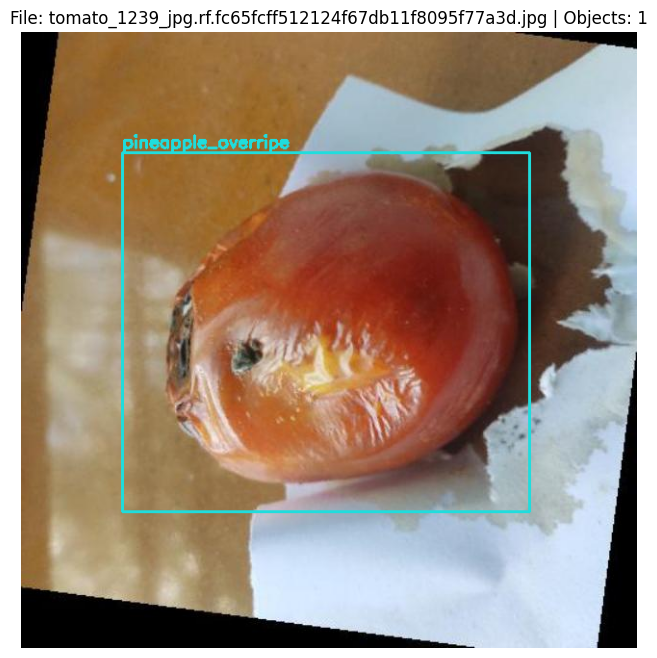

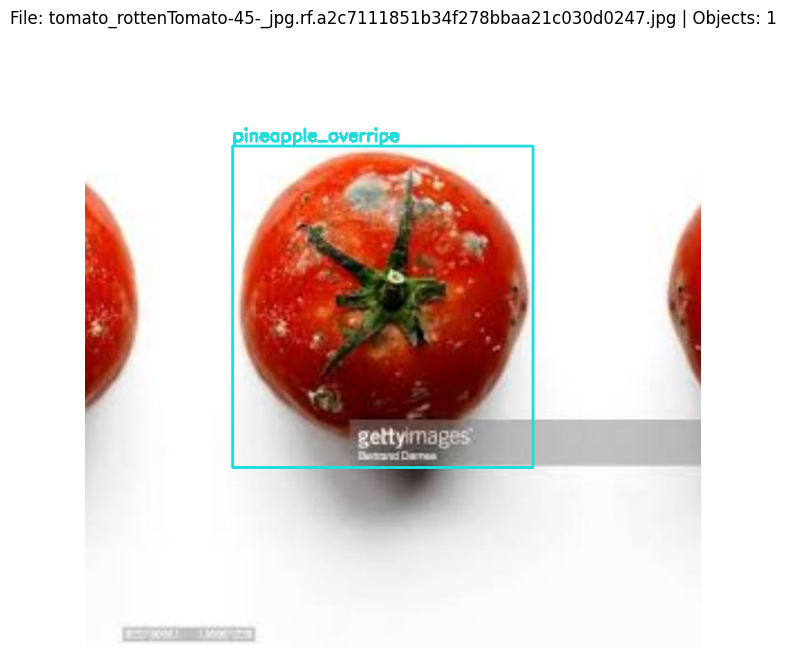

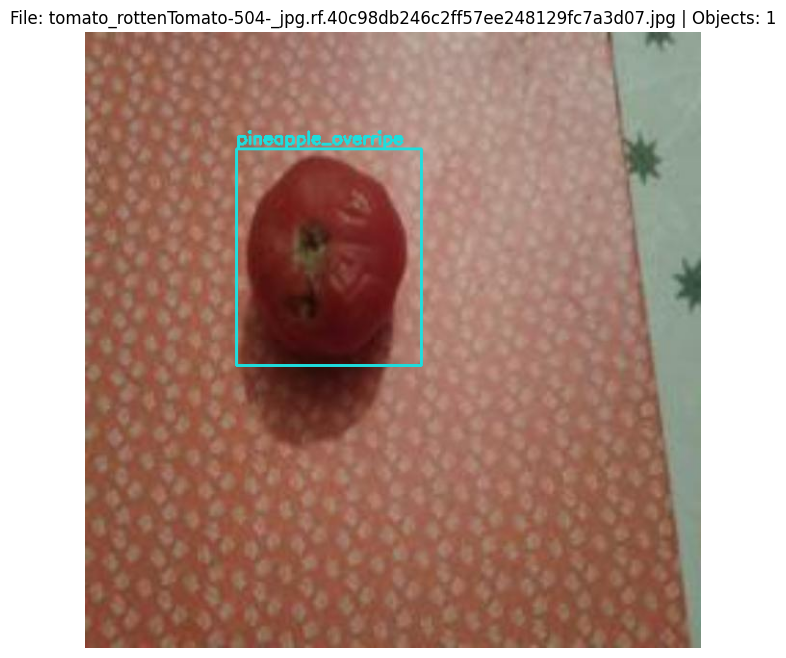

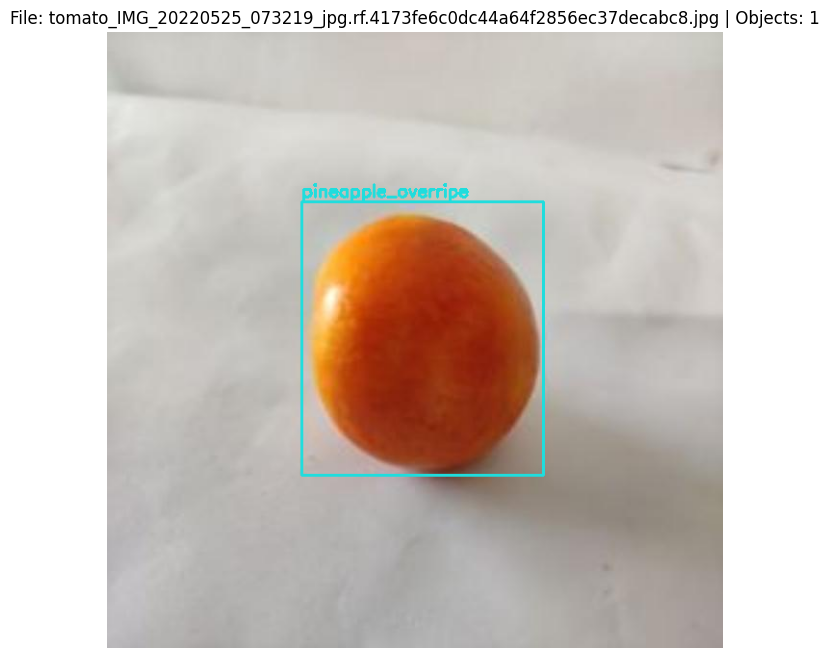

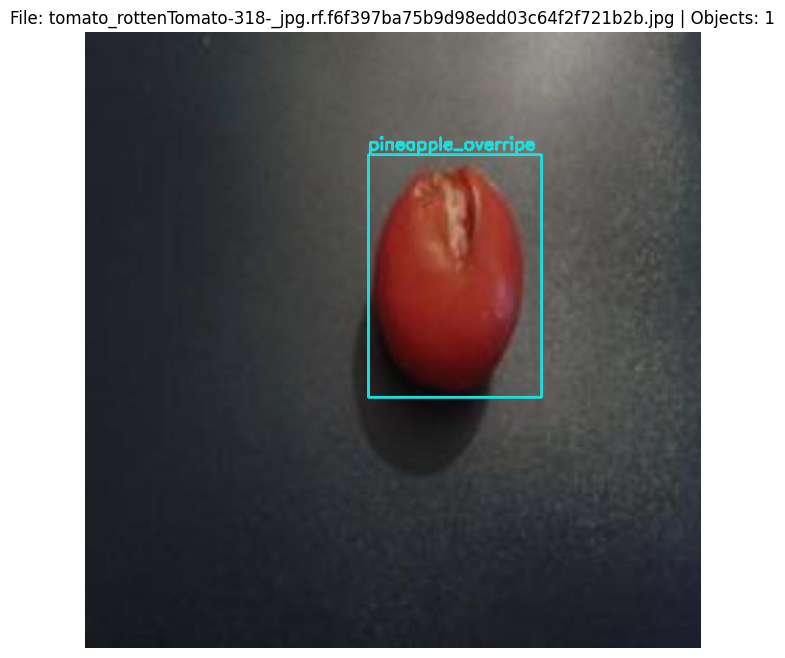

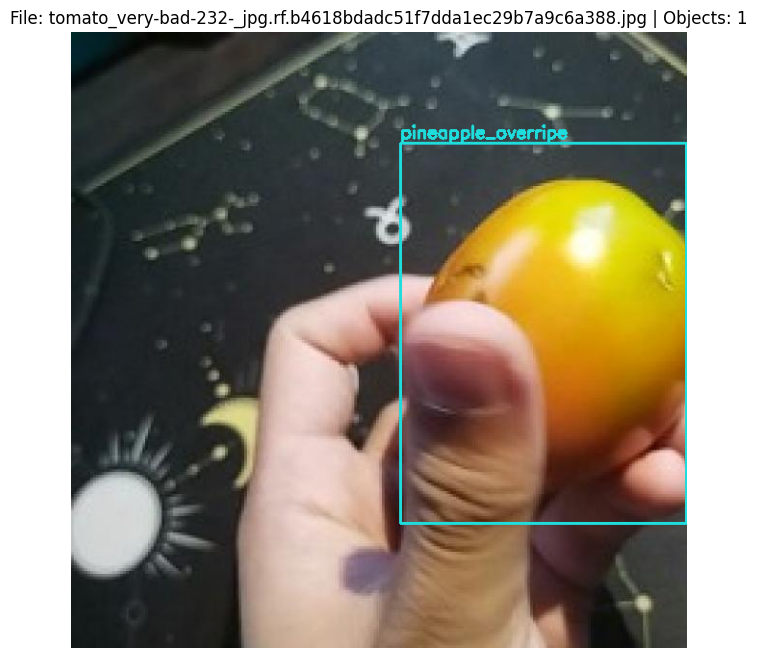

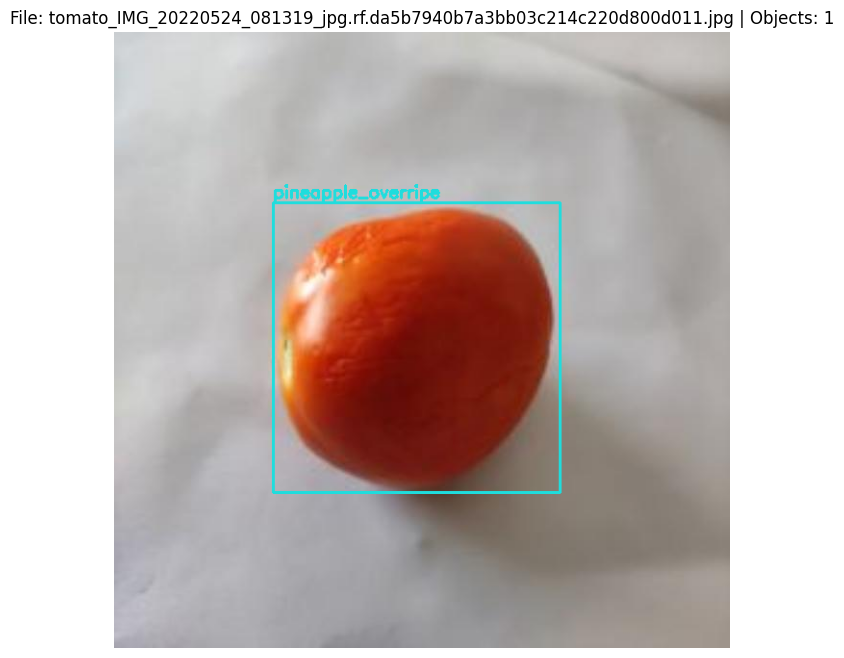

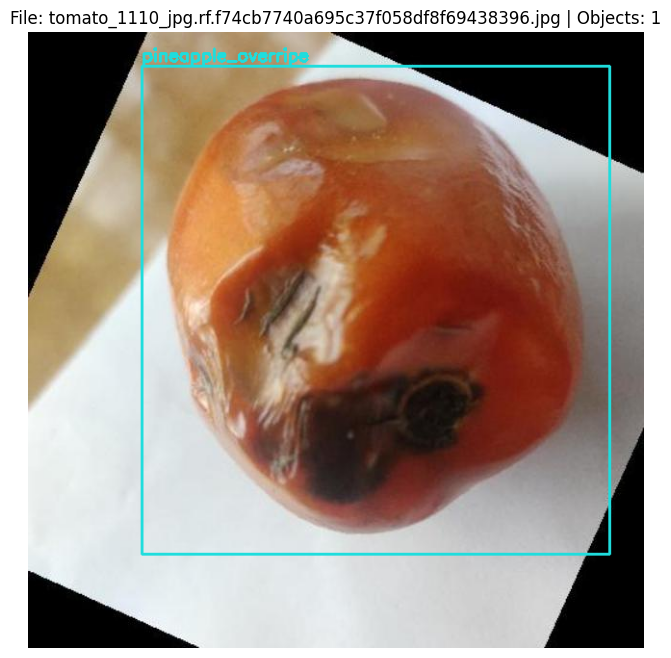

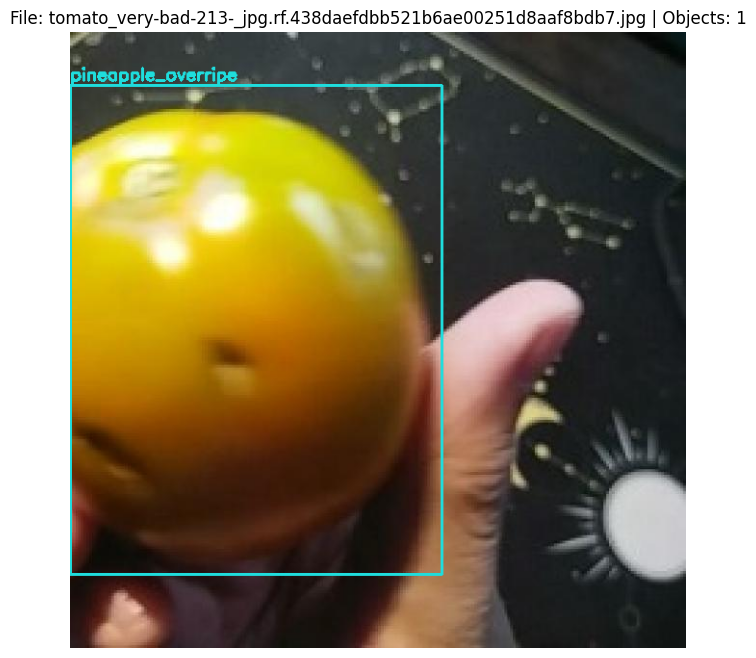

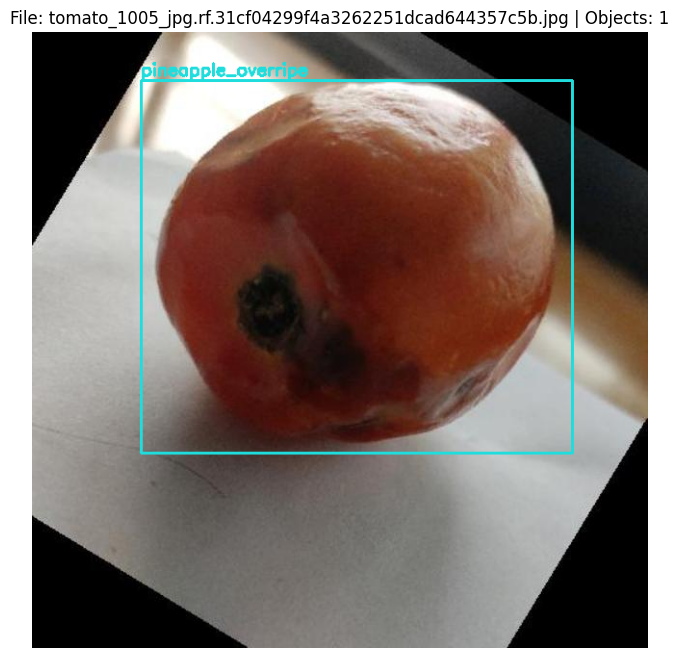

In [ ]:
import os
import random
import cv2
import matplotlib.pyplot as plt
from pathlib import Path

MASTER_CLASSES = {
    0: "apple_unripe", 1: "apple_ripe", 2: "apple_overripe",
    3: "banana_unripe", 4: "banana_ripe", 5: "banana_overripe",
    6: "pineapple_unripe", 7: "pineapple_ripe", 8: "pineapple_overripe",
}

COLORS = [(random.randint(0, 255), random.randint(0, 255), random.randint(0, 255)) for _ in range(9)]
DATASET_DIR = Path("merged_dataset")


def read_yolo_labels(label_path, img_w, img_h):
    """Đọc file txt YOLO và chuyển đổi tọa độ tương đối sang tọa độ pixel tuyệt đối."""
    boxes = []
    if not label_path.exists():
        return boxes

    with open(label_path, "r", encoding="utf-8") as f:
        for line in f:
            parts = line.strip().split()
            if len(parts) >= 5:
                cls_id = int(parts[0])
                x_center, y_center, w, h = map(float, parts[1:5])

                x1 = int((x_center - w / 2) * img_w)
                y1 = int((y_center - h / 2) * img_h)
                x2 = int((x_center + w / 2) * img_w)
                y2 = int((y_center + h / 2) * img_h)

                boxes.append((cls_id, x1, y1, x2, y2))
    return boxes

def visualize_sample(image_path, label_path):
    """Render ảnh và vẽ BBox cùng tên class lên ảnh."""
    img = cv2.imread(str(image_path))
    if img is None:
        print(f"[ERROR] Không thể đọc ảnh: {image_path}")
        return

    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    h, w, _ = img.shape

    boxes = read_yolo_labels(label_path, w, h)

    for box in boxes:
        cls_id, x1, y1, x2, y2 = box
        color = COLORS[cls_id] if cls_id < len(COLORS) else (255, 0, 0)
        label_name = MASTER_CLASSES.get(cls_id, f"Unknown_{cls_id}")

        cv2.rectangle(img, (x1, y1), (x2, y2), color, 2)
        cv2.putText(img, label_name, (x1, max(y1 - 5, 10)), cv2.FONT_HERSHEY_SIMPLEX, 0.6, color, 2)

    plt.figure(figsize=(8, 8))
    plt.imshow(img)
    plt.axis("off")
    plt.title(f"File: {image_path.name} | Objects: {len(boxes)}")
    plt.show()

def check_random_samples(dataset_dir, split="valid", num_samples=5):
    """Lấy ngẫu nhiên N ảnh từ tập chỉ định để kiểm tra tổng quát."""
    dataset_path = Path(dataset_dir)
    img_dir = dataset_path / split / "images"
    lbl_dir = dataset_path / split / "labels"

    if not img_dir.exists():
        print(f"[ERROR] Không tìm thấy thư mục: {img_dir}")
        return

    all_images = list(img_dir.glob("*.*"))
    if not all_images:
        print("[WARN] Thư mục ảnh trống.")
        return

    samples = random.sample(all_images, min(num_samples, len(all_images)))

    print(f"\n[INFO] Đang hiển thị {len(samples)} ảnh ngẫu nhiên từ tập '{split}'...")
    for img_path in samples:
        lbl_path = lbl_dir / f"{img_path.stem}.txt"
        visualize_sample(img_path, lbl_path)

def check_specific_class(dataset_dir, target_class_id, split="valid", num_samples=5):
    """Tìm và hiển thị chỉ những ảnh có chứa một class ID cụ thể."""
    dataset_path = Path(dataset_dir)
    img_dir = dataset_path / split / "images"
    lbl_dir = dataset_path / split / "labels"

    valid_images = []

    if not lbl_dir.exists():
        print(f"[ERROR] Không tìm thấy thư mục nhãn: {lbl_dir}")
        return

    for lbl_path in lbl_dir.glob("*.txt"):
        with open(lbl_path, "r", encoding="utf-8") as f:
            if any(int(line.split()[0]) == target_class_id for line in f if line.strip()):
                for ext in [".jpg", ".jpeg", ".png"]:
                    img_path = img_dir / f"{lbl_path.stem}{ext}"
                    if img_path.exists():
                        valid_images.append((img_path, lbl_path))
                        break

    if not valid_images:
        print(f"[WARN] Không tìm thấy ảnh nào chứa class ID {target_class_id} trong tập '{split}'.")
        return

    samples = random.sample(valid_images, min(num_samples, len(valid_images)))
    class_name = MASTER_CLASSES.get(target_class_id, "Unknown")

    print(f"\n[INFO] Đang hiển thị {len(samples)} ảnh chứa class '{class_name}' (ID: {target_class_id})...")
    for img_path, lbl_path in samples:
        visualize_sample(img_path, lbl_path)


if __name__ == "__main__":
    # 2. Chạy hàm này để focus trực tiếp vào kiểm tra bbox của Dứa hỏng (ID: 8)
    check_specific_class(DATASET_DIR, target_class_id=7, split="valid", num_samples=10)

[INFO] Đang thống kê số lượng Bounding Box...

--- KẾT QUẢ THỐNG KÊ ---
0 - apple_unripe      : 6277 boxes
1 - apple_ripe        : 6056 boxes
2 - apple_overripe    : 6396 boxes
3 - banana_unripe     : 6605 boxes
4 - banana_ripe       : 6802 boxes
5 - banana_overripe   : 8178 boxes
6 - tomato_unripe     : 9595 boxes
7 - tomato_ripe       : 9752 boxes
8 - tomato_bad        : 8798 boxes

[INFO] Đã lưu biểu đồ thành file: class_distribution_chart.png


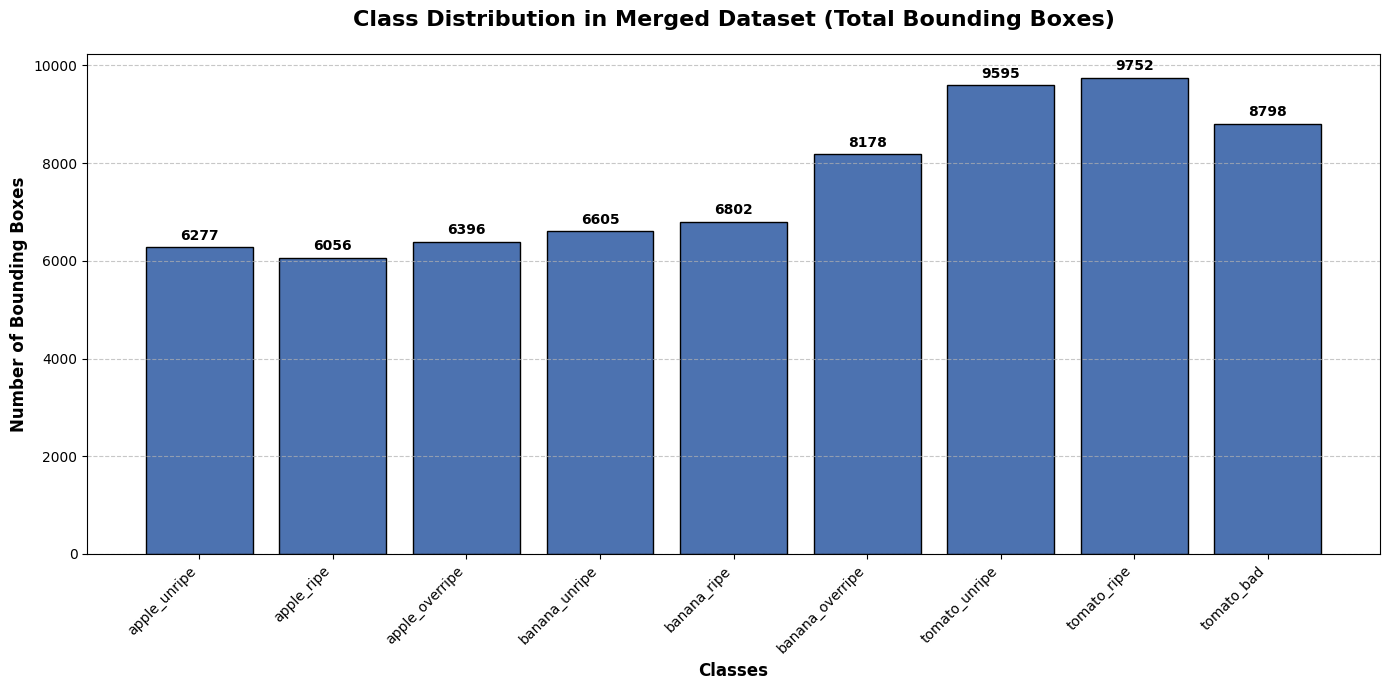

In [ ]:
import os
from pathlib import Path
from collections import Counter
import matplotlib.pyplot as plt

# =========================
# CONFIG
# =========================

DATASET_DIR = Path("balanced_dataset")
SPLITS = ["train", "valid", "test"]

MASTER_CLASSES = {
    0: "apple_unripe", 1: "apple_ripe", 2: "apple_overripe",
    3: "banana_unripe", 4: "banana_ripe", 5: "banana_overripe",
    6: "tomato_unripe", 7: "tomato_ripe", 8: "tomato_bad",
}


def count_bounding_boxes():
    """Đọc toàn bộ file txt và đếm số lượng bbox cho từng class."""
    class_counts = Counter()

    for split in SPLITS:
        label_dir = DATASET_DIR / split / "labels"

        if not label_dir.exists():
            continue

        for label_file in label_dir.glob("*.txt"):
            with open(label_file, "r", encoding="utf-8") as f:
                for line in f:
                    parts = line.strip().split()
                    if len(parts) >= 5:
                        try:
                            cls_id = int(parts[0])
                            class_counts[cls_id] += 1
                        except ValueError:
                            pass

    return class_counts

def plot_distribution(counts):
    """Vẽ biểu đồ cột thể hiện sự phân bổ của các class."""
    classes = []
    box_counts = []

    # Đảm bảo in ra đủ 9 class, kể cả những class có 0 box
    for cls_id in range(len(MASTER_CLASSES)):
        classes.append(MASTER_CLASSES[cls_id])
        box_counts.append(counts.get(cls_id, 0))

    # Thiết lập kích thước và vẽ biểu đồ
    plt.figure(figsize=(14, 7))
    bars = plt.bar(classes, box_counts, color='#4C72B0', edgecolor='black')

    # Ghi số lượng cụ thể lên đầu mỗi cột
    for bar in bars:
        yval = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2, yval + (max(box_counts) * 0.01),
                 int(yval), ha='center', va='bottom', fontsize=10, fontweight='bold')

    # Trang trí biểu đồ
    plt.title("Class Distribution in Merged Dataset (Total Bounding Boxes)", fontsize=16, fontweight='bold', pad=20)
    plt.xlabel("Classes", fontsize=12, fontweight='bold')
    plt.ylabel("Number of Bounding Boxes", fontsize=12, fontweight='bold')
    plt.xticks(rotation=45, ha='right', fontsize=10)
    plt.grid(axis='y', linestyle='--', alpha=0.7)

    plt.tight_layout()

    # Lưu và hiển thị
    plt.savefig("class_distribution_chart.png", dpi=300)
    print("\n[INFO] Đã lưu biểu đồ thành file: class_distribution_chart.png")
    plt.show()

# =========================
# RUN
# =========================

if __name__ == "__main__":
    if not DATASET_DIR.exists():
        print(f"[ERROR] Không tìm thấy thư mục: {DATASET_DIR}")
    else:
        print("[INFO] Đang thống kê số lượng Bounding Box...")
        counts = count_bounding_boxes()

        print("\n--- KẾT QUẢ THỐNG KÊ ---")
        for cls_id in range(len(MASTER_CLASSES)):
            name = MASTER_CLASSES[cls_id]
            count = counts.get(cls_id, 0)
            print(f"{cls_id} - {name:<18}: {count} boxes")

        plot_distribution(counts)

In [ ]:
! pip install albumentations opencv-python

In [ ]:
# import os
# import cv2
# import random
# import shutil
# from pathlib import Path
# from collections import defaultdict
# import albumentations as A

# # =========================
# # CONFIG
# # =========================
# INPUT_DIR = Path("merged_dataset")
# OUTPUT_DIR = Path("balanced_dataset")

# # Mốc target (Chỉ áp dụng cho tập Train)
# TARGET_MIN = 6000  # Nếu dưới mốc này -> Augment (Sinh thêm)
# TARGET_MAX = 7500  # Nếu chạm mốc này -> Cắt bỏ (Downsample)

# # Pipeline Augmentation an toàn (Không làm méo/sai lệch đặc trưng màu)
# AUG_TRANSFORM = A.Compose([
#     A.HorizontalFlip(p=0.5),
#     A.RandomBrightnessContrast(brightness_limit=0.2, contrast_limit=0.2, p=0.7),
#     A.GaussianBlur(blur_limit=3, p=0.3),
# ], bbox_params=A.BboxParams(format='yolo', min_visibility=0.3))

# # =========================
# # UTILS
# # =========================
# def ensure_dirs():
#     if OUTPUT_DIR.exists():
#         print(f"[WARN] Thư mục {OUTPUT_DIR} đã tồn tại. Dữ liệu sẽ được ghi đè/thêm vào.")

#     for split in ["train", "valid", "test"]:
#         (OUTPUT_DIR / split / "images").mkdir(parents=True, exist_ok=True)
#         (OUTPUT_DIR / split / "labels").mkdir(parents=True, exist_ok=True)

# def read_yolo_label(label_path):
#     boxes = []
#     with open(label_path, "r", encoding="utf-8") as f:
#         for line in f:
#             parts = line.strip().split()
#             if len(parts) >= 5:
#                 # Ép qua float trước rồi mới lấy int để xử lý trường hợp class_id bị lưu là '1.0'
#                 cls_id = int(float(parts[0]))
#                 coords = list(map(float, parts[1:5]))
#                 boxes.append(coords + [cls_id])
#     return boxes

# def write_yolo_label(label_path, boxes):
#     with open(label_path, "w", encoding="utf-8") as f:
#         for box in boxes:
#             # Đảm bảo ép về int trước khi ghi ra file
#             cls_id = int(box[4])
#             coords = " ".join([f"{x:.6f}" for x in box[:4]])
#             f.write(f"{cls_id} {coords}\n")
# # =========================
# # CORE LOGIC
# # =========================
# def process_split(split):
#     input_img_dir = INPUT_DIR / split / "images"
#     input_lbl_dir = INPUT_DIR / split / "labels"
#     out_img_dir = OUTPUT_DIR / split / "images"
#     out_lbl_dir = OUTPUT_DIR / split / "labels"

#     if not input_img_dir.exists():
#         return

#     print(f"\n[INFO] Đang xử lý tập: {split.upper()}...")

#     images = list(input_img_dir.glob("*.*"))
#     random.shuffle(images) # Xáo trộn ngẫu nhiên để tránh bias

#     current_counts = defaultdict(int)
#     kept_images = []

#     # -----------------------------------------
#     # PHASE 1: DOWNSAMPLE (Áp dụng cho mọi split)
#     # -----------------------------------------
#     for img_path in images:
#         lbl_path = input_lbl_dir / f"{img_path.stem}.txt"
#         if not lbl_path.exists(): continue

#         boxes = read_yolo_label(lbl_path)
#         if not boxes: continue

#         # Đếm thử xem nếu thêm ảnh này vào thì có bị vượt MAX_BOXES không
#         temp_counts = defaultdict(int)
#         for box in boxes:
#             temp_counts[box[4]] += 1

#         should_keep = True
#         for cls_id, count in temp_counts.items():
#             if current_counts[cls_id] + count > TARGET_MAX:
#                 should_keep = False
#                 break

#         # Nếu an toàn (không vượt MAX), ta giữ lại ảnh này
#         if should_keep:
#             for cls_id, count in temp_counts.items():
#                 current_counts[cls_id] += count

#             # Copy file
#             shutil.copy(img_path, out_img_dir / img_path.name)
#             shutil.copy(lbl_path, out_lbl_dir / lbl_path.name)
#             kept_images.append((out_img_dir / img_path.name, out_lbl_dir / lbl_path.name))

#     print(f"  -> Xong Downsample. Giữ lại {len(kept_images)} ảnh.")
#     for k, v in dict(current_counts).items():
#         print(f"     Class {k}: {v} boxes")

#     # -----------------------------------------
#     # PHASE 2: UPSAMPLE / AUGMENT (CHỈ áp dụng cho Train)
#     # -----------------------------------------
#     if split == "train":
#         print(f"\n  [INFO] Đang chạy Augmentation cho các class thiểu số...")
#         aug_idx = 0

#         # Lặp cho đến khi tất cả các class đạt TARGET_MIN
#         while True:
#             needs_augment = {cls: current_counts[cls] for cls in current_counts if current_counts[cls] < TARGET_MIN}
#             if not needs_augment:
#                 break # Tất cả đã đạt mốc

#             # Trích xuất 1 class đang thiếu nhiều nhất để xử lý
#             target_cls = min(needs_augment, key=needs_augment.get)

#             # Tìm 1 ảnh ngẫu nhiên có chứa target_cls từ danh sách ĐÃ GIỮ
#             candidates = []
#             for img_p, lbl_p in kept_images:
#                 boxes = read_yolo_label(lbl_p)
#                 if any(b[4] == target_cls for b in boxes):
#                     candidates.append((img_p, lbl_p, boxes))

#             if not candidates:
#                 print(f"  -> [CẢNH BÁO] Không có ảnh nào chứa class {target_cls} để augment!")
#                 current_counts[target_cls] = TARGET_MIN # Ép thoát vòng lặp
#                 continue

#             # Tiến hành sinh ảnh mới
#             src_img_p, src_lbl_p, boxes = random.choice(candidates)
#             image = cv2.imread(str(src_img_p))
#             if image is None: continue
#             image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

#             try:
#                 # Chạy Albumentations
#                 transformed = AUG_TRANSFORM(image=image, bboxes=boxes)
#                 transformed_image = transformed['image']
#                 transformed_bboxes = transformed['bboxes']

#                 if not transformed_bboxes: continue # Bỏ qua nếu sau khi xoay/lật bị mất box

#                 aug_idx += 1
#                 new_img_name = f"aug_{aug_idx}_{src_img_p.name}"
#                 new_lbl_name = f"aug_{aug_idx}_{src_lbl_p.name}"

#                 new_img_path = out_img_dir / new_img_name
#                 new_lbl_path = out_lbl_dir / new_lbl_name

#                 # Lưu ảnh mới
#                 transformed_image = cv2.cvtColor(transformed_image, cv2.COLOR_RGB2BGR)
#                 cv2.imwrite(str(new_img_path), transformed_image)

#                 # Lưu nhãn mới
#                 write_yolo_label(new_lbl_path, transformed_bboxes)

#                 # Cập nhật số đếm
#                 for box in transformed_bboxes:
#                     current_counts[box[4]] += 1

#                 # Thêm ảnh vừa sinh vào danh sách để có thể augment tiếp nếu cần
#                 kept_images.append((new_img_path, new_lbl_path))

#             except Exception as e:
#                 pass # Bỏ qua nếu có lỗi sinh ảnh do box vượt quá viền

#         print(f"  -> Xong Upsample. Đã sinh thêm {aug_idx} ảnh ảo.")
#         print("  -> Phân phối cuối cùng tập Train:")
#         for k, v in dict(current_counts).items():
#             print(f"     Class {k}: {v} boxes")

# # =========================
# # RUN
# # =========================
# if __name__ == "__main__":
#     ensure_dirs()

#     # Copy file data.yaml sang thư mục mới
#     if (INPUT_DIR / "data.yaml").exists():
#         shutil.copy(INPUT_DIR / "data.yaml", OUTPUT_DIR / "data.yaml")

#     for split in ["train", "valid", "test"]:
#         process_split(split)

#     print("\n[DONE] Hoàn tất quá trình tạo Balanced Dataset tại thư mục:", OUTPUT_DIR.absolute())


[INFO] Đang xử lý tập: TRAIN...
  -> Xong Downsample. Giữ lại 20341 ảnh.
     Class 8: 7500 boxes
     Class 7: 7500 boxes
     Class 2: 3071 boxes
     Class 5: 6937 boxes
     Class 6: 7500 boxes
     Class 0: 3586 boxes
     Class 4: 5426 boxes
     Class 1: 1859 boxes
     Class 3: 4518 boxes

  [INFO] Đang chạy Augmentation cho các class thiểu số...
  -> Xong Upsample. Đã sinh thêm 3470 ảnh ảo.
  -> Phân phối cuối cùng tập Train:
     Class 8: 7500 boxes
     Class 7: 7500 boxes
     Class 2: 6000 boxes
     Class 5: 7173 boxes
     Class 6: 7500 boxes
     Class 0: 6001 boxes
     Class 4: 6001 boxes
     Class 1: 6013 boxes
     Class 3: 6002 boxes

[INFO] Đang xử lý tập: VALID...
  -> Xong Downsample. Giữ lại 2813 ảnh.
     Class 6: 2044 boxes
     Class 7: 1865 boxes
     Class 8: 1176 boxes
     Class 3: 429 boxes
     Class 4: 527 boxes
     Class 5: 650 boxes
     Class 2: 264 boxes
     Class 0: 179 boxes
     Class 1: 23 boxes

[INFO] Đang xử lý tập: TEST...
  -> Xong Do

# tranining

In [ ]:
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Tham số -q (quiet) giúp ẩn log các file đang giải nén để trình duyệt không bị treo/lag
# Tham số -d / chỉ định giải nén từ thư mục gốc, giúp khôi phục đúng đường dẫn /content/balanced_dataset
!unzip -q "/content/drive/MyDrive/balanced_dataset.zip" -d /

print("[DONE] Đã giải nén toàn bộ dataset vào thư mục /content/balanced_dataset sẵn sàng để train!")

[DONE] Đã giải nén toàn bộ dataset vào thư mục /content/balanced_dataset sẵn sàng để train!


In [ ]:
!pip install ultralytics

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.3/41.3 kB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 36.1 MB/s eta 0:00:00


In [ ]:
from ultralytics import YOLO

model = YOLO("yolo26s.pt")

model.train(
    data="/content/balanced_dataset/data.yaml",
    epochs=80,
    imgsz=640,
    batch=64,
    device=0,

    patience=20,
    pretrained=True,
    plots=True,

    mosaic=0.2,
    mixup=0.0,
    hsv_h=0.01,
    hsv_s=0.3,
    hsv_v=0.25,
    translate=0.05,
    scale=0.25,
    fliplr=0.5,
)

Ultralytics 8.4.77 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=64, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/balanced_dataset/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dis=6.0, distill_model=None, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=80, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.01, hsv_s=0.3, hsv_v=0.25, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo26s.pt, momentum=0.937, mosaic=0.2, multi_scale=0.0, name=train-3, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto

KeyboardInterrupt: 

In [ ]:
from ultralytics import YOLO

# Load model
model = YOLO("/content/runs/detect/train-3/weights/best.pt")

# Predict trên 1 ảnh
results = model.predict(
    source="/content/pngtree-spoiled-apple-defeated-a-rotten-apple-on-a-stump-among-a-spoiled-crop-photo-image_30095140.jpg",
    conf=0.25,
    save=True
)

# In kết quả
for r in results:
    boxes = r.boxes

    for box in boxes:
        cls_id = int(box.cls[0])
        conf = float(box.conf[0])

        print(
            f"Class: {model.names[cls_id]}, "
            f"Conf: {conf:.3f}"
        )


image 1/1 /content/pngtree-spoiled-apple-defeated-a-rotten-apple-on-a-stump-among-a-spoiled-crop-photo-image_30095140.jpg: 448x640 4 apple_overripes, 28.7ms
Speed: 6.4ms preprocess, 28.7ms inference, 0.7ms postprocess per image at shape (1, 3, 448, 640)
Results saved to /content/runs/detect/predict-2
Class: apple_overripe, Conf: 0.881
Class: apple_overripe, Conf: 0.858
Class: apple_overripe, Conf: 0.767
Class: apple_overripe, Conf: 0.711
